In [28]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

In [8]:
def f(x, w):
    res = x @ w
    return res

In [15]:
x = np.array([0,1,0,1,0])
v = np.array([4,2,2,5,6])
w = np.array([4,3,3,7,8])

In [9]:
f(x, w)

np.int64(10)

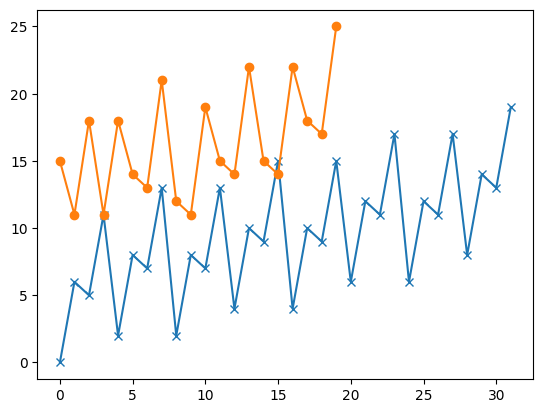

In [52]:
combinations = list(itertools.product([0, 1], repeat=5))   
X=np.array(combinations, dtype=np.int8)



res = np.array([])
res_v = np.array([])
for i in X:
    #res.append([(i @ w), (i @ v)])
    res = np.append(res, [i @ w])
    res_v = np.append(res_v, [i @ v])
    #res.append((i @ w))
    #res_v.append((i @ v))
    #print(res)

# 1) remove points where c > 10
x2 = X[res > 10]
y2 = res[res > 10]

plt.plot(res_v, '-x')
plt.plot(y2, '-o')
plt.show()

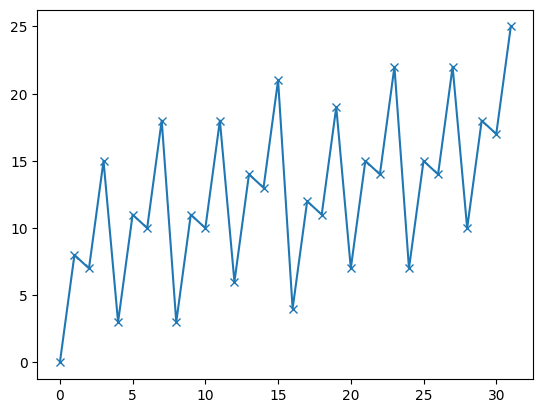

In [39]:
combinations = list(itertools.product([0, 1], repeat=5))   
X=np.array(combinations, dtype=np.int8)
res = np.array([])
for i in X:
    res = np.append(res, (i @ w))
plt.plot(res, '-x')
plt.show()

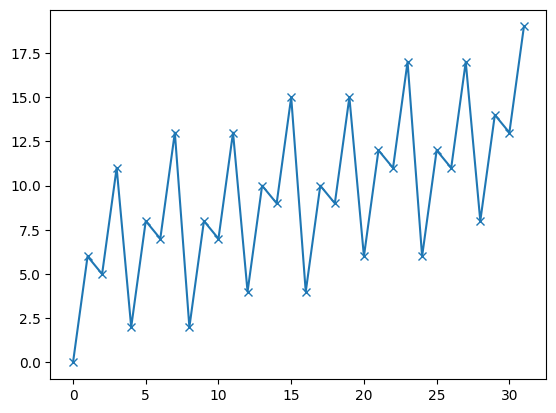

In [40]:
res = np.array([])
for i in X:
    res = np.append(res, (i @ v))
plt.plot(res, '-x')
plt.show()

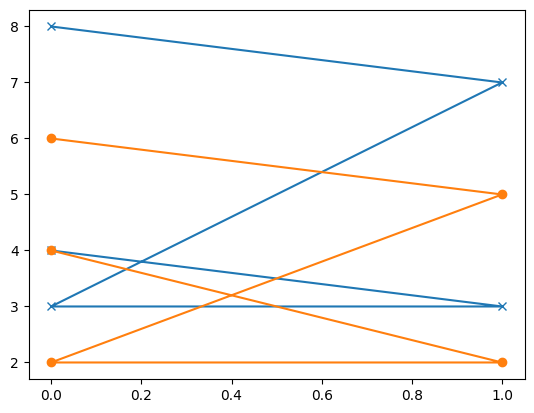

In [16]:
plt.plot(x, w, '-x')
plt.plot(x,v,'-o')
plt.show()

In [ ]:
import numpy as np


def get_binary_combinations_numpy(n):
    """
    Generates all 2^n binary vectors using pure NumPy broadcasting.
    This is the fastest method for creating the entire matrix at once.
    
    Logic:
    1. Create a range of numbers from 0 to 2^n - 1.
    2. Convert these numbers to their binary representation using bitwise operations.
    """
    # 1. Create a column vector of integers from 0 to 2^n - 1
    # Shape: (2^n, 1)
    # Example for n=3: [[0], [1], ..., [7]]
    nums = np.arange(2**n)[:, None]
    
    # 2. Create a row vector of bit shifts
    # Shape: (1, n)
    # Example for n=3: [[2, 1, 0]]
    shifts = np.arange(n - 1, -1, -1)
    
    # 3. Use broadcasting to perform bitwise AND check
    # We shift the bits of 'nums' down and check if the LSB is 1
    # equivalent to: (nums // (2**shifts)) % 2
    binary_matrix = (nums >> shifts) & 1
    
    return binary_matrix.astype(np.int8)

def get_binary_combinations_itertools(n):
    """
    Generates combinations using itertools.product.
    This is often more readable and easier to iterate over row-by-row
    without storing the huge matrix in memory first.
    """
    # product([0, 1], repeat=n) generates tuples: (0,0,0), (0,0,1), etc.
    combinations = list(itertools.product([0, 1], repeat=n))
    
    return np.array(combinations, dtype=np.int8)

if __name__ == "__main__":
    N = 3
    
    print(f"--- Generating {{0,1}}^{N} using Pure NumPy ---")
    result_np = get_binary_combinations_numpy(N)
    print(f"Shape: {result_np.shape}")
    print(result_np)
    print("\n")

    print(f"--- Generating {{0,1}}^{N} using Itertools ---")
    result_iter = get_binary_combinations_itertools(N)
    print(result_iter)
    
    # Performance Note
    print("\n--- Performance Note ---")
    print("For small n (n < 25), the NumPy method is extremely fast.")
    print(f"For n={N}, total elements: {2**N}")
    
    # Example of how broadcasting works internally in the numpy function:
    # nums   = [[0], [1], [2], [3]...] (vertical)
    # shifts = [2, 1, 0] (horizontal)
    # 
    # 5 >> [2, 1, 0] -> [1, 2, 5]
    # [1, 2, 5] & 1  -> [1, 0, 1] (Binary for 5)

--- Generating {0,1}^3 using Pure NumPy ---
Shape: (8, 3)
[[0 0 0]
 [0 0 1]
 [0 1 0]
 [0 1 1]
 [1 0 0]
 [1 0 1]
 [1 1 0]
 [1 1 1]]


--- Generating {0,1}^3 using Itertools ---
[[0 0 0]
 [0 0 1]
 [0 1 0]
 [0 1 1]
 [1 0 0]
 [1 0 1]
 [1 1 0]
 [1 1 1]]

--- Performance Note ---
For small n (n < 25), the NumPy method is extremely fast.
For n=3, total elements: 8
